# Tier 0 · Notebook 1 — Autograd from Scratch

> **Goal:** build reverse-mode automatic differentiation (the thing PyTorch's `.backward()` does) starting from a single scalar and the chain rule. Everything else in this whole curriculum — optimizers, MLPs, CNNs, transformers, GPT — is "what you can build *once you have `backward()`*". So this is the most important notebook. Do it slowly.

**What you will be able to do by the end**
- Explain what a *computational graph* is and why gradients flow backward through it.
- Derive and hand-implement the local derivative of every basic op (`+`, `*`, `**`, `tanh`, `exp`, `relu`).
- Implement the **multivariate chain rule** correctly (the `+=` that trips everyone up).
- Do a **topological sort** and understand *why* backprop needs one.
- Verify your gradients against **numerical finite differences** and against **PyTorch**.
- Build a neuron → layer → MLP on top of your engine and train it.

**Ground rule for this notebook:** pure Python + `math`. No NumPy, no framework in the core. We only bring in PyTorch at the very end, to *check our work*.


## 0. The one idea: derivatives measure sensitivity

A derivative $\dfrac{\partial L}{\partial x}$ answers a very concrete question:

> *If I nudge $x$ by a tiny amount $h$, how much does the output $L$ change?*

Formally,
$$\frac{\partial L}{\partial x} = \lim_{h \to 0}\frac{L(x+h) - L(x)}{h}.$$

Training a neural net is nothing but: compute a loss $L$, ask *"how does each weight affect $L$?"*, then nudge every weight a little in the direction that reduces $L$. The "how does each weight affect $L$" part — for *millions* of weights, efficiently — is exactly what autograd gives us.

**An analogy.** Picture a giant audio mixing board with thousands of sliders, and a single VU meter showing "how bad the mix sounds" (that's the loss $L$). The derivative $\partial L/\partial(\text{slider}_i)$ tells you, for each slider, *which way and how hard to push it to make the meter drop*. A big positive derivative → pushing that slider up makes things worse, so pull it down. A derivative near zero → that slider barely matters right now. Training is just: read all the derivatives, nudge every slider a hair in the improving direction, repeat. The whole trick of backprop is computing **all** those "which-way-to-push" numbers cheaply, in one pass.

**The sign matters, not just the size.** Because we'll *subtract* the gradient (`slider -= lr * grad`), the sign encodes direction automatically: positive grad ⇒ we decrease the slider, negative grad ⇒ we increase it. Keep that in mind — later, when a gradient prints as `-1.5`, it literally means "increasing this input increases the output."

Let's build the intuition numerically first, before we build the machine.


In [1]:
import math

def f(x):
    return 3*x**2 - 4*x + 5

# Numerical derivative at x = 3 using the definition above.
x = 3.0
h = 1e-6
numerical = (f(x + h) - f(x)) / h
analytic  = 6*x - 4          # d/dx (3x^2 - 4x + 5) = 6x - 4
print(f"numerical df/dx at x=3 : {numerical:.6f}")
print(f"analytic  df/dx at x=3 : {analytic:.6f}")


numerical df/dx at x=3 : 14.000003
analytic  df/dx at x=3 : 14.000000


They match. Good. Two takeaways:

1. **We can always sanity-check a gradient numerically** with a tiny nudge $h$. Keep this trick — we'll use it as our test harness for the whole engine.
2. Doing this "nudge each input" trick for *every* parameter would cost one forward pass **per parameter**. A GPT has billions. That's hopeless. Reverse-mode autograd computes *all* the derivatives in **a single backward pass**. That efficiency is the whole point.


## 1. The computational graph

Any expression is really a *graph* of tiny operations. Take
$$L = (a\cdot b) + c.$$
Break it into atoms:
- $e = a \cdot b$  (a `*` node with parents $a, b$)
- $L = e + c$      (a `+` node with parents $e, c$)

```
   a ──┐
        (*)── e ──┐
   b ──┘           (+)── L
              c ──┘
```

**Forward pass:** walk left→right, compute each node's value.

**Backward pass:** walk right→left, and at each node apply the **chain rule** to convert "gradient of $L$ w.r.t. *my output*" into "gradient of $L$ w.r.t. *my inputs*".

To do this we need each value to *remember how it was produced* — its parents and which operation made it. So instead of a bare `float`, we wrap every number in an object. Let's start.


## 1.5 The chain rule, worked by hand (the engine's whole job)

Before we automate anything, let's do backprop *manually* on the tiny graph above so the machine we build next has nothing mysterious in it. Take concrete numbers: $a=2,\ b=-3,\ c=10$.

**Forward pass** (left → right, just compute values):
$$e = a \cdot b = 2 \cdot (-3) = -6, \qquad L = e + c = -6 + 10 = 4.$$

**Backward pass** (right → left, compute how $L$ responds to each node). We want $\dfrac{\partial L}{\partial a}$, $\dfrac{\partial L}{\partial b}$, $\dfrac{\partial L}{\partial c}$. We get them by chaining *local* derivatives — each node only needs to know how its own output depends on its own inputs.

Start at the output: $\dfrac{\partial L}{\partial L} = 1$ (a thing's sensitivity to itself is 1). This is the seed.

*The `+` node* $L = e + c$. Its two local derivatives are both 1 ($\partial L/\partial e = 1$, $\partial L/\partial c = 1$), because adding $c$ shifts $L$ one-for-one. So:
$$\frac{\partial L}{\partial e} = \underbrace{\frac{\partial L}{\partial L}}_{1}\cdot\underbrace{\frac{\partial L}{\partial e}}_{1} = 1, \qquad \frac{\partial L}{\partial c} = 1.$$
**Takeaway: a `+` node just passes the gradient straight through to both inputs, unchanged.**

*The `*` node* $e = a \cdot b$. Local derivatives: $\partial e/\partial a = b$ and $\partial e/\partial b = a$ (product rule). Now **chain** — multiply the gradient arriving from above ($\partial L/\partial e = 1$) by each local derivative:
$$\frac{\partial L}{\partial a} = \frac{\partial L}{\partial e}\cdot\frac{\partial e}{\partial a} = 1 \cdot b = -3, \qquad \frac{\partial L}{\partial b} = \frac{\partial L}{\partial e}\cdot\frac{\partial e}{\partial a}\Big|_{a} = 1 \cdot a = 2.$$
**Takeaway: a `*` node swaps its inputs — each input's gradient is the *other* input's value, times the incoming gradient.**

So $\nabla = (\partial L/\partial a,\ \partial L/\partial b,\ \partial L/\partial c) = (-3,\ 2,\ 1)$. Let's confirm with finite differences (nudge each input, watch $L$):


In [2]:
def L_of(a, b, c):
    return a*b + c

a0, b0, c0, h = 2.0, -3.0, 10.0, 1e-6
dLda = (L_of(a0+h, b0, c0) - L_of(a0-h, b0, c0)) / (2*h)
dLdb = (L_of(a0, b0+h, c0) - L_of(a0, b0-h, c0)) / (2*h)
dLdc = (L_of(a0, b0, c0+h) - L_of(a0, b0, c0-h)) / (2*h)
print(f"dL/da = {dLda:+.4f}   (hand-derived: b = -3)")
print(f"dL/db = {dLdb:+.4f}   (hand-derived: a = +2)")
print(f"dL/dc = {dLdc:+.4f}   (hand-derived: 1)")


dL/da = -3.0000   (hand-derived: b = -3)
dL/db = +2.0000   (hand-derived: a = +2)
dL/dc = +1.0000   (hand-derived: 1)


**What to notice.** The numbers match our hand derivation exactly: $(-3, +2, +1)$. Read them as sentences — *"nudging $a$ up by 1 pushes $L$ down by 3"* (because $b$ is negative), *"nudging $c$ up by 1 pushes $L$ up by 1"* (adding passes through). That's the entire content of backprop.

Doing this by hand is fine for 3 nodes. For a network with millions, we need to (1) store each node's local rule, and (2) apply the chain in the right order automatically. **That is exactly the object we build now** — every `_backward` closure you're about to write is just one of the "takeaway" rules above (`+` passes through, `*` swaps), and the topological sort is just "right → left in the correct order."


## 2. The `Value` object — a number that remembers

We store four things per node:
- `data` — the actual scalar value (the forward result).
- `grad` — $\dfrac{\partial L}{\partial \text{this}}$, i.e. how the *final* output depends on this node. **Starts at 0** (before backprop, this node has had no measured effect).
- `_prev` — the set of parent nodes it was built from.
- `_backward` — a closure that knows how to push this node's `grad` into its parents' `grad` (empty for leaf nodes / inputs).

Start with just the skeleton and addition. We'll grow it op by op.


In [3]:
class Value:
    """A scalar that records the graph that produced it, so it can backprop."""

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0                 # dL/d(self); 0 until backprop fills it in
        self._backward = lambda: None   # how to send grad to my parents; leaves do nothing
        self._prev = set(_children)     # the nodes I was built from
        self._op = _op                  # what op made me (for printing/debug only)

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # d(out)/d(self) = 1 and d(out)/d(other) = 1, so by the chain rule
            # each parent just receives out.grad unchanged.
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out


### Why `+=` and not `=`?  (the single most important line)

Look at `self.grad += 1.0 * out.grad`. Why *accumulate*?

Because a node can feed **more than one** downstream consumer. Consider $L = a + a = 2a$. The graph has $a$ flowing into the `+` node **twice**. The true gradient is $\frac{\partial L}{\partial a} = 2$. If we *overwrote* (`=`), the second contribution would clobber the first and we'd get $1$. By *adding*, both paths contribute and we get $1 + 1 = 2$. ✔

This is just the **multivariate chain rule**: if $L$ depends on $x$ through several paths, sum the contributions:
$$\frac{\partial L}{\partial x} = \sum_{\text{paths } p} \frac{\partial L}{\partial x}\Big|_p.$$

Every `_backward` we write from here on uses `+=` for exactly this reason. It also means we **must reset grads to 0** before each new backward pass — a real gotcha, and exactly why PyTorch makes you call `optimizer.zero_grad()`.


## 3. Multiplication — the first *interesting* local derivative

For `out = self * other`:
$$\frac{\partial\,\text{out}}{\partial\,\text{self}} = \text{other}, \qquad \frac{\partial\,\text{out}}{\partial\,\text{other}} = \text{self}.$$

So each parent's incoming gradient is *the other parent's data* times `out.grad`. This "swap" is the essence of the product rule. Let's add it (we'll rebuild the class cumulatively at the end; for now just read the method).


In [4]:
def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
        self.grad  += other.data * out.grad   # d(out)/d(self)  = other
        other.grad += self.data  * out.grad   # d(out)/d(other) = self
    out._backward = _backward
    return out

# (shown standalone for reading; the full class in section 6 includes it)
print(__mul__.__doc__ or "product rule: swap the operands")


product rule: swap the operands


## 4. The backward pass needs a *topological order*

We have per-node local rules. But in what **order** do we call them?

Rule: **you can only compute a node's gradient after every node that consumes it has already contributed.** In graph terms, process nodes in *reverse topological order* — a linear ordering where every node comes *before* its parents' consumers... concretely: build a topological order of the graph (each node appears after all its children), then walk it **in reverse**.

Why topological and not just "recurse"? Because of shared subgraphs again (the diamond): if $x$ feeds two branches that both feed $L$, we must wait until *both* branches have pushed their gradient into $x$ before $x$ pushes onward. A topo sort guarantees that.

The algorithm:
1. **DFS** from the output, appending each node to a list *after* visiting all its children → that list is a valid topological order (children before parents).
2. Set the output's own grad to **1.0** (since $\frac{\partial L}{\partial L} = 1$).
3. Walk the list **in reverse** (parents before children — i.e. output first), calling each node's `_backward`.


In [5]:
def backward(self):
    topo = []
    visited = set()

    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:      # visit all children first...
                build_topo(child)
            topo.append(v)             # ...then append self  => children precede parents

    build_topo(self)
    self.grad = 1.0                    # dL/dL = 1: seed the output
    for node in reversed(topo):        # output first, inputs last
        node._backward()               # push grad from node -> its parents

# (also folded into the full class below)
print("topo sort + reverse walk defined")


topo sort + reverse walk defined


## 5. More ops: `**`, `tanh`, `exp`, `relu`, and the division/subtraction sugar

We need a few more atoms to build real networks. Each one: **derive the local derivative, then code it.**

**Power** `out = self ** n` (constant integer/float `n`):
$$\frac{d}{dx}x^n = n\,x^{n-1}.$$

**tanh** `out = tanh(self)` (a classic squashing nonlinearity that maps any real number into $(-1, 1)$):
$$\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x).$$
Let's actually *derive* this rather than quote it, because it's a great chain-rule + quotient-rule exercise. Start from the definition $\tanh(x) = \dfrac{e^x - e^{-x}}{e^x + e^{-x}}$. Write $u = e^x - e^{-x}$ (numerator) and $v = e^x + e^{-x}$ (denominator). Note $u' = e^x + e^{-x} = v$ and $v' = e^x - e^{-x} = u$. By the quotient rule:
$$\tanh'(x) = \frac{u'v - uv'}{v^2} = \frac{v\cdot v - u\cdot u}{v^2} = \frac{v^2 - u^2}{v^2} = 1 - \frac{u^2}{v^2} = 1 - \tanh^2(x).$$
Notice the final form is written purely in terms of the **output** $t=\tanh(x)$: it's $1 - t^2$. That's a recurring efficiency trick — the backward pass reuses the number the forward pass already computed, so we store `t` once and never recompute the exponentials. Intuitively $1 - t^2$ also tells a story: when the unit is *saturated* ($t \approx \pm 1$), the derivative $\approx 0$ — the neuron stops responding to nudges. That vanishing slope at the extremes is exactly the "saturation" problem that motivates ReLU later.

**exp** `out = e^{self}`:
$$\frac{d}{dx}e^x = e^x = \text{out.data}.$$
This is the one function that is its own derivative — so the local gradient *is* the output we already computed. Even cleaner than tanh: nothing to store beyond `out.data` itself.

**ReLU** `out = max(0, self)` (the workhorse of modern nets):
$$\frac{d}{dx}\mathrm{ReLU}(x) = \begin{cases}1 & x > 0\\ 0 & x \le 0\end{cases}.$$
A gradient *gate*: it passes gradient through when the unit was active, blocks it otherwise.

Subtraction, division, and negation we get *for free* by composing the atoms:
$-x = x \cdot (-1)$, $a - b = a + (-b)$, $a / b = a \cdot b^{-1}$. Building them from existing ops means their gradients already work — no new `_backward` needed.


## 6. The full engine (one clean class)

Here's everything above assembled. This is your reusable `Value` engine — later notebooks will import this exact idea. Read every `_backward` and match it to the derivative we derived.


In [6]:
import math

class Value:
    """Reverse-mode autodiff over scalars. ~micrograd, built up from first principles."""

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    # ---- primitive ops (each defines value + local gradient) ----------------
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad     # d/dx e^x = e^x = out.data
        out._backward = _backward
        return out

    def relu(self):
        out = Value(self.data if self.data > 0 else 0.0, (self,), 'relu')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    # ---- composed / convenience ops (no new gradient logic needed) ----------
    def __neg__(self):        return self * -1
    def __sub__(self, other): return self + (-other)
    def __radd__(self, other): return self + other          # other + self
    def __rmul__(self, other): return self * other          # other * self
    def __rsub__(self, other): return other + (-self)        # other - self
    def __truediv__(self, other):  return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    # ---- the backward pass --------------------------------------------------
    def backward(self):
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


## 7. First real backprop — reproduce a known-by-hand example

Let's run the canonical Karpathy example so you can check the numbers against a hand derivation.

$$n = x_1 w_1 + x_2 w_2 + b, \qquad o = \tanh(n).$$

With $x_1=2,\,x_2=0,\,w_1=-3,\,w_2=1,\,b=6.8813735870195432$ (chosen so $n$ comes out clean), we expect:
- $o \approx 0.7071$
- $\frac{\partial o}{\partial x_1} = w_1\,(1-o^2)$, and similarly the other partials.


In [7]:
x1 = Value(2.0);  x2 = Value(0.0)
w1 = Value(-3.0); w2 = Value(1.0)
b  = Value(6.8813735870195432)

n = x1*w1 + x2*w2 + b
o = n.tanh()
o.backward()

print(f"o        = {o.data:.4f}")
print(f"do/dx1   = {x1.grad:.4f}   (expected w1*(1-o^2) = {(-3.0)*(1-o.data**2):.4f})")
print(f"do/dw1   = {w1.grad:.4f}   (expected x1*(1-o^2) = { 2.0 *(1-o.data**2):.4f})")
print(f"do/dw2   = {w2.grad:.4f}")
print(f"do/db    = {b.grad:.4f}    (expected 1*(1-o^2)  = {(1-o.data**2):.4f})")


o        = 0.7071
do/dx1   = -1.5000   (expected w1*(1-o^2) = -1.5000)
do/dw1   = 1.0000   (expected x1*(1-o^2) = 1.0000)
do/dw2   = 0.0000
do/db    = 0.5000    (expected 1*(1-o^2)  = 0.5000)


**What to notice.** Every analytic prediction matches the engine's output — our `backward()` is doing real calculus. Now *read* the gradients as sentences (recall: sign = direction, magnitude = strength):

- `do/dx1 = -1.5` → the input $x_1$ has a **negative** effect: turning $x_1$ up would push the output $o$ **down** (makes sense — its weight $w_1 = -3$ is negative). It also has the **largest** magnitude, so $x_1$ is the most influential input here.
- `do/dw2 = 0.0` → weight $w_2$ has **zero** gradient. Why? Because its input $x_2 = 0$, so nudging $w_2$ multiplies by 0 and changes nothing. A dead input silences its weight's gradient — a pattern you'll see again with ReLU (a zero activation kills the gradient behind it).
- `do/db = 0.5` → the bias passes straight through the `+` nodes, so its gradient is just the `tanh` local derivative $1 - o^2$.

These three readings *are* the `+`-passes-through and `*`-swaps rules from Section 1.5, now happening automatically. Let's make them visible.


### See it: draw the computational graph

Numbers in a table are abstract. Let's *look* at the graph we just built and backpropped through. The drawer below is pure `matplotlib` (no Graphviz needed): it collects every node reachable from the output, lays them out left→right by **depth** (leaves/inputs on the left, output on the right), and prints each node's `op`, its **`data`** (filled in on the forward pass) and its **`grad`** (filled in on the backward pass).

Read it as: forward flows **left→right** (compute `data`), backward flows **right→left** (compute `grad`). Every arrow is one application of the chain rule. Blue = an op produced this node; red = a leaf (an input/parameter).


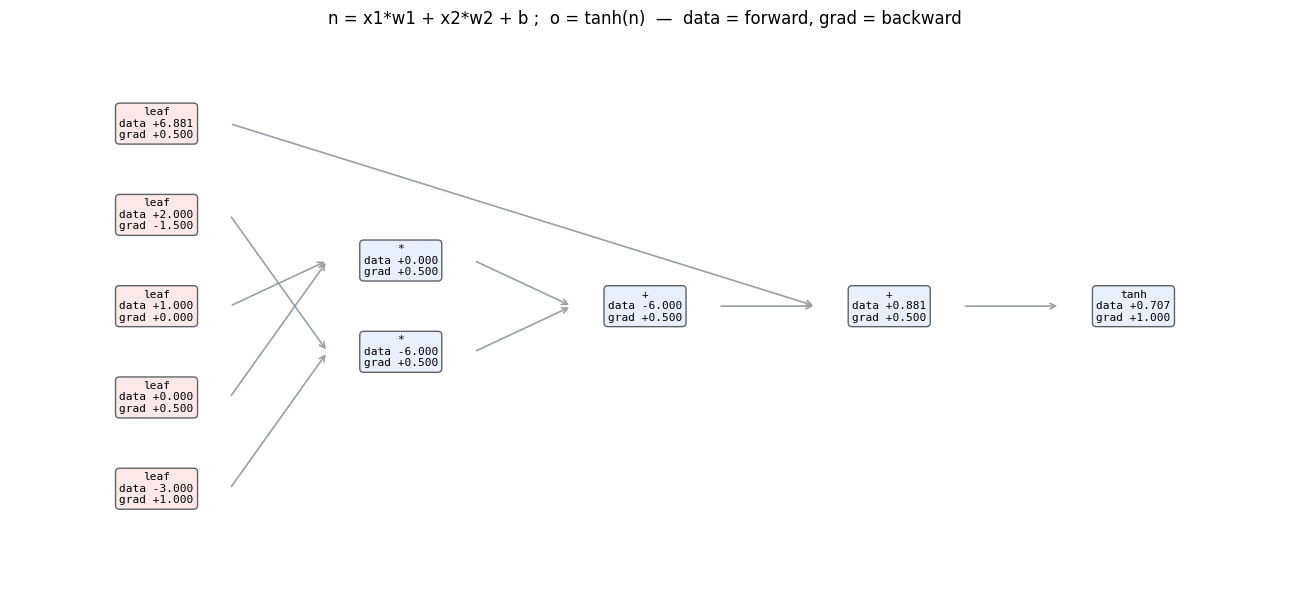

In [8]:
import matplotlib.pyplot as plt
from collections import defaultdict
%matplotlib inline

def draw_graph(root, figsize=(13, 6), title="Computational graph"):
    # 1. collect all nodes + parent->child edges reachable from the output
    nodes, edges = set(), []
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for ch in v._prev:
                edges.append((ch, v))   # child feeds into v
                build(ch)
    build(root)

    # 2. depth = longest path from any leaf, so inputs land at x=0, output at the right
    depth = {}
    def d(v):
        if v not in depth:
            depth[v] = 0 if not v._prev else 1 + max(d(p) for p in v._prev)
        return depth[v]
    for v in nodes:
        d(v)

    # 3. stack the nodes of each depth vertically, centered
    layers = defaultdict(list)
    for v in nodes:
        layers[depth[v]].append(v)
    pos = {}
    for lvl, vs in layers.items():
        for i, v in enumerate(sorted(vs, key=lambda n: n.data)):
            pos[v] = (lvl, i - (len(vs) - 1) / 2)

    # 4. draw
    fig, ax = plt.subplots(figsize=figsize)
    for ch, pa in edges:
        (x0, y0), (x1, y1) = pos[ch], pos[pa]
        ax.annotate("", xy=(x1 - 0.30, y1), xytext=(x0 + 0.30, y0),
                    arrowprops=dict(arrowstyle="->", color="#9aa0a6", lw=1.2))
    for v in nodes:
        x, y = pos[v]
        label = f"{v._op if v._op else 'leaf'}\ndata {v.data:+.3f}\ngrad {v.grad:+.3f}"
        ax.text(x, y, label, ha="center", va="center", fontsize=8, family="monospace",
                bbox=dict(boxstyle="round,pad=0.35",
                          fc="#e8f0fe" if v._prev else "#fce8e6", ec="#5f6368"))
    ys = [p[1] for p in pos.values()]
    ax.set_xlim(-0.6, max(depth.values()) + 0.6)
    ax.set_ylim(min(ys) - 1, max(ys) + 1)
    ax.axis("off")
    ax.set_title(title + "  —  data = forward, grad = backward")
    plt.tight_layout()
    plt.show()

draw_graph(o, title="n = x1*w1 + x2*w2 + b ;  o = tanh(n)")


Trace one path with your finger: `x1` (red leaf, `grad -1.500`) → its `*` node → the `+` chain → `n` → `tanh` → `o` (`grad 1.000`, since it's the output). The gradient on `x1` is `w1·(1-o²)` — exactly the number the table printed. **That picture is the whole notebook in one image.** We'll reuse `draw_graph` to debug graphs later.


## 8. Test the engine: numerical gradient check

Never trust an autodiff engine you haven't gradient-checked. We compare each analytic grad to a finite-difference estimate $\frac{L(x+h)-L(x-h)}{2h}$ (the *central* difference — more accurate than the one-sided version from section 0).

We test a deliberately nasty expression that exercises `*`, `+`, `**`, `/`, `exp`, `tanh`, `relu` and — importantly — **variable reuse** (`a` appears many times), which is exactly where the `+=` accumulation matters.


In [9]:
def f_scalar(a_, b_, c_):
    # a nasty mix that reuses inputs several times
    return (a_*b_ + a_.exp()).tanh() + (c_ * a_**2).relu() + a_ / (b_ + 2.0)

# analytic grads via our engine
a, b, c = Value(0.7), Value(-1.3), Value(2.1)
L = f_scalar(a, b, c)
L.backward()
analytic = {'a': a.grad, 'b': b.grad, 'c': c.grad}

# numerical grads via central differences on plain floats
def f_float(av, bv, cv):
    L = f_scalar(Value(av), Value(bv), Value(cv))
    return L.data

h = 1e-6
base = (0.7, -1.3, 2.1)
numerical = {}
for i, name in enumerate('abc'):
    up   = list(base); up[i]   += h
    down = list(base); down[i] -= h
    numerical[name] = (f_float(*up) - f_float(*down)) / (2*h)

print(f"{'param':>6} {'analytic':>14} {'numerical':>14} {'abs err':>12}")
for name in 'abc':
    err = abs(analytic[name] - numerical[name])
    print(f"{name:>6} {analytic[name]:>14.8f} {numerical[name]:>14.8f} {err:>12.2e}")
assert all(abs(analytic[n]-numerical[n]) < 1e-4 for n in 'abc'), "gradient check FAILED"
print("\n✅ gradient check passed")


 param       analytic      numerical      abs err
     a     4.62341532     4.62341532     7.35e-11
     b    -1.17863792    -1.17863792     1.20e-10
     c     0.49000000     0.49000000     1.31e-10

✅ gradient check passed


**What to notice.** The errors are around $10^{-10}$ — not exactly zero, and that's *expected*. The finite-difference estimate isn't perfect truth: it has two competing error sources. Too large an $h$ and you measure a secant line instead of the tangent (approximation error, $\sim h^2$ for the central difference); too small an $h$ and $L(x+h)$ and $L(x-h)$ round to nearly the same float, so you subtract two almost-equal numbers and lose precision (roundoff error, $\sim \varepsilon/h$). The sweet spot for central differences sits near $h \approx 10^{-6}$, giving errors around $10^{-10}$–$10^{-11}$. **Rule of thumb: if your analytic and numerical gradients agree to ~1e-6 or better, your backward pass is correct; if they disagree at 1e-2 or worse, you have a bug.** This is the first thing to run whenever you implement a new op — and we just proved our whole engine passes it even on an expression that reuses inputs (where the `+=` accumulation had to be right).


## 9. Build a neural net *on top of* the engine

Now the payoff. A single **neuron** is $\;\text{out} = \phi\!\left(\sum_i w_i x_i + b\right)$ — exactly the ops we have. Stack neurons into a **layer**, stack layers into an **MLP**. None of this needs new calculus; the engine already differentiates through all of it.


In [10]:
import random
random.seed(1337)

class Neuron:
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)   # w·x + b
        return act.tanh() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout, **kw):
        self.neurons = [Neuron(nin, **kw) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        # last layer linear (no squash) so outputs aren't bounded to (-1,1)
        self.layers = [Layer(sizes[i], sizes[i+1], nonlin=(i != len(nouts)-1))
                       for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

model = MLP(3, [4, 4, 1])
print(f"MLP with {len(model.parameters())} parameters")


MLP with 41 parameters


## 10. Train it — the full loop, by hand

Tiny binary-ish regression: 4 samples, targets in $\{-1, +1\}$. Loss = mean squared error. The loop is the same four steps you'll write for the rest of your life:

1. **forward** — predictions from inputs
2. **loss** — a single number measuring wrongness
3. **backward** — `zero_grad` then `loss.backward()` to fill every `p.grad`
4. **update** — nudge each param *against* its gradient: `p.data -= lr * p.grad`

Watch the `zero_grad` — remember section 2, grads accumulate, so we must clear them each step or gradients from previous steps leak in.


In [11]:
xs = [[ 2.0,  3.0, -1.0],
      [ 3.0, -1.0,  0.5],
      [ 0.5,  1.0,  1.0],
      [ 1.0,  1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]   # desired outputs

lr = 0.05
losses = []                          # record the loss each step so we can plot it
for step in range(100):
    # 1. forward
    ypred = [model(x) for x in xs]
    # 2. loss (MSE)
    loss = sum((yp - yt)**2 for yp, yt in zip(ypred, ys)) * (1.0/len(ys))
    # 3. backward
    for p in model.parameters():
        p.grad = 0.0            # <-- zero_grad, or grads accumulate across steps
    loss.backward()
    # 4. update (vanilla SGD)
    for p in model.parameters():
        p.data -= lr * p.grad
    losses.append(loss.data)
    if step % 10 == 0 or step == 99:
        print(f"step {step:3d}  loss {loss.data:.6f}")

print("\nfinal predictions:", [round(model(x).data, 3) for x in xs])
print("targets          :", ys)


step   0  loss 0.773215
step  10  loss 0.011869
step  20  loss 0.000270
step  30  loss 0.000014
step  40  loss 0.000005
step  50  loss 0.000003
step  60  loss 0.000002
step  70  loss 0.000001
step  80  loss 0.000001
step  90  loss 0.000001
step  99  loss 0.000000

final predictions: [1.001, -1.0, -1.0, 0.999]
targets          : [1.0, -1.0, -1.0, 1.0]


The loss falls and predictions move toward the targets. **You just trained a neural network on an autograd engine you wrote from scratch.** That's the entire foundation of deep learning in ~80 lines.

Let's plot the loss curve — the single most-looked-at chart in all of deep learning. A healthy curve drops fast then flattens as the model runs out of easy wins.


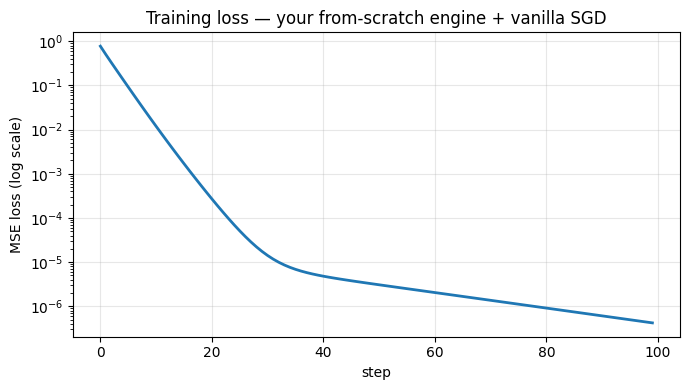

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(losses, lw=2)
plt.yscale("log")                    # log scale: the late, tiny improvements stay visible
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Training loss — your from-scratch engine + vanilla SGD")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Verify against PyTorch

Final trust step: build the *same* graph in PyTorch and confirm the gradients match ours to floating-point precision. This is the "pure from scratch, then verify vs the framework" discipline we'll use in every notebook.


In [13]:
import torch

# --- our engine ---
a = Value(0.7); b = Value(-1.3); c = Value(2.1)
L = (a*b + a.exp()).tanh() + (c * a**2).relu() + a / (b + 2.0)
L.backward()
ours = (a.grad, b.grad, c.grad)

# --- the same expression in torch ---
at = torch.tensor(0.7, dtype=torch.double, requires_grad=True)
bt = torch.tensor(-1.3, dtype=torch.double, requires_grad=True)
ct = torch.tensor(2.1, dtype=torch.double, requires_grad=True)
Lt = torch.tanh(at*bt + torch.exp(at)) + torch.relu(ct * at**2) + at / (bt + 2.0)
Lt.backward()
theirs = (at.grad.item(), bt.grad.item(), ct.grad.item())

print(f"{'':>4}{'ours':>16}{'torch':>16}{'diff':>12}")
for name, o, t in zip('abc', ours, theirs):
    print(f"{name:>4}{o:>16.10f}{t:>16.10f}{abs(o-t):>12.2e}")
assert all(abs(o-t) < 1e-9 for o, t in zip(ours, theirs))
print("\n✅ matches PyTorch to ~1e-9")


                ours           torch        diff
   a    4.6234153156    4.6234153156    0.00e+00
   b   -1.1786379165   -1.1786379165    0.00e+00
   c    0.4900000000    0.4900000000    0.00e+00

✅ matches PyTorch to ~1e-9


## 12. What you built, in one paragraph

You built **reverse-mode automatic differentiation**: a `Value` scalar that records the computational graph as it computes forward, a per-op *local derivative* rule stored as a closure, a **topological sort** to order the backward pass, and the **multivariate chain rule** (`+=` accumulation) to combine gradients from shared paths. On top of that you built neuron/layer/MLP and trained with vanilla SGD. This *is* PyTorch's autograd, minus tensors and CUDA.

## 13. Exercises (do these — reproduction is the skill)
1. **Add `log` and `sigmoid`.** Derive the local derivatives, implement them, and gradient-check. ($\sigma'(x)=\sigma(x)(1-\sigma(x))$.)
2. **Cross-entropy from atoms.** Implement softmax + cross-entropy loss using only your ops, and gradient-check against PyTorch's `F.cross_entropy`.
3. **Break the `+=`.** Change one `+=` to `=` and find the smallest expression whose gradient becomes wrong. Explain *why* using the diamond graph.
4. **Extend the graph drawer.** Use our `draw_graph` on `o = (a*b + c).tanh()`. Then extend it to *color each node by the magnitude of its `grad`* (a gradient heatmap) — where in the graph is the signal strongest?
5. **Second derivatives?** Why can't this engine compute $\frac{\partial^2 L}{\partial x^2}$ directly, and what would you change? (Hint: the grads would themselves need to be `Value`s.)

## 14. Interview / residency framing
- *"Walk me through what `loss.backward()` does."* → graph, topo sort, reverse walk, chain rule, grad accumulation.
- *"Why `zero_grad`?"* → grads accumulate by design (multivariate chain rule); stale grads leak otherwise.
- *"Why is reverse-mode the right choice for deep learning?"* → one output (scalar loss), many inputs (params); reverse-mode gets *all* input grads in one pass, cost ∝ forward pass. Forward-mode would cost one pass per input.
- *"Where does this break at scale?"* → scalars are absurdly slow; real autograd is over *tensors* so one node = a whole matrix op. **That's the next notebook.**

---
**Next:** *Tier 0 · Notebook 2 — Tensors & a tensor-valued autograd (broadcasting, matmul, the vectorized chain rule).*


## 📚 References & papers

This notebook reproduces / builds on:

- **Learning representations by back-propagating errors** — Rumelhart, Hinton & Williams (1986), *Nature*. The backpropagation algorithm.
- **Automatic differentiation in machine learning: a survey** — Baydin et al. (2018), JMLR. Reverse-mode autodiff.
- **micrograd** — Karpathy (2020). The scalar autograd engine this notebook rebuilds.